# 05. AI Tools Adoption & Sentiments

This notebook details developer AI adoption, sentiment, and tooling popularity from 2023 to 2025. We cover:
1. Sentiment on benefits vs. threats of AI
2. Trust in AI outputs (2025)
3. Top AI Search and Developer tools worked with
4. AI selection and usage patterns across developer roles

In [1]:
import os
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set style for visuals
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["font.size"] = 12

# Resolve path to sql_connector relative to this notebook
current_dir = os.path.abspath('')
project_root = os.path.dirname(current_dir)
silver_utils_dir = os.path.join(project_root, 'Data Warehouse', 'Silver Layer', 'utils')
sys.path.append(silver_utils_dir)

# Ensure the images output directory exists
images_dir = os.path.join(current_dir, 'images')
os.makedirs(images_dir, exist_ok=True)

from sql_connector import SQLConnector

db = SQLConnector("Stack_Overflow_Survey")
db.connect()

Successfully Connected to Stack_Overflow_Survey


### 1. Developer Sentiment on AI Benefits (2023-2025)

Let's see if developer sentiments about the benefits of AI tools have become more optimistic or cautious.

c:\Users\Ayush\Git Repo\Stack-Over-Flow-Survey-Data-Engineering-Project\Data Warehouse\Silver Layer\utils\sql_connector.py:46: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql_query(query, self.conn)


Query executed successfully


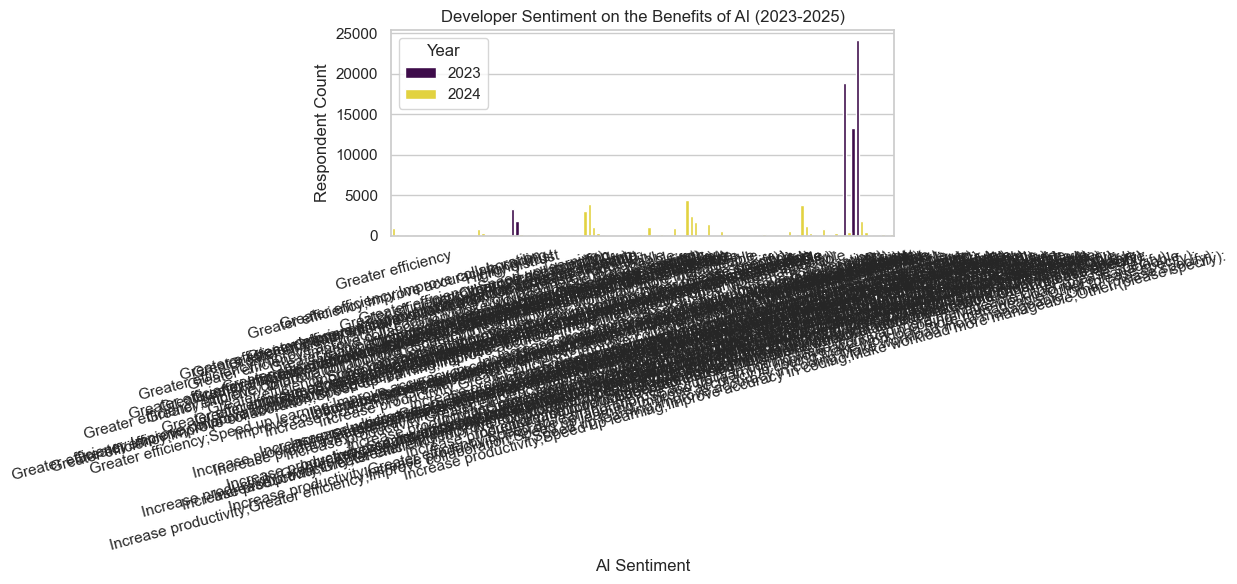

In [2]:
ai_query = """
SELECT 
    YEAR(f.SurveyYear) AS Year,
    o.AIBen AS AI_Benefit_Sentiment,
    COUNT(DISTINCT f.ResponseKey) AS Count
FROM Snowflake.Fact_Survey_Core f
JOIN Snowflake.Dim_AICentral c ON f.Dim_AICentralID = c.Dim_AICentralID
JOIN Snowflake.Dim_AIOpinions o ON c.Dim_AIOpinionsID = o.Dim_AIOpinionsID
WHERE o.AIBen IS NOT NULL AND o.AIBen <> '' AND o.AIBen <> 'Unknown'
GROUP BY YEAR(f.SurveyYear), o.AIBen;
"""
df_ai = db.read_query(ai_query)

if df_ai is not None and not df_ai.empty:
    plt.figure(figsize=(12, 6))
    sns.barplot(data=df_ai, x='AI_Benefit_Sentiment', y='Count', hue='Year', palette='viridis')
    plt.title('Developer Sentiment on the Benefits of AI (2023-2025)')
    plt.xlabel('AI Sentiment')
    plt.ylabel('Respondent Count')
    plt.xticks(rotation=15)
    plt.legend(title='Year')
    plt.tight_layout()
    plt.savefig(os.path.join(images_dir, '05_ai_sentiment.png'), dpi=300)
    plt.show()
else:
    print("No AI sentiment data available.")

### 2. Developer Trust in AI Outputs (2025)

How much do developers trust AI tool outputs?

c:\Users\Ayush\Git Repo\Stack-Over-Flow-Survey-Data-Engineering-Project\Data Warehouse\Silver Layer\utils\sql_connector.py:46: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql_query(query, self.conn)


Query executed successfully


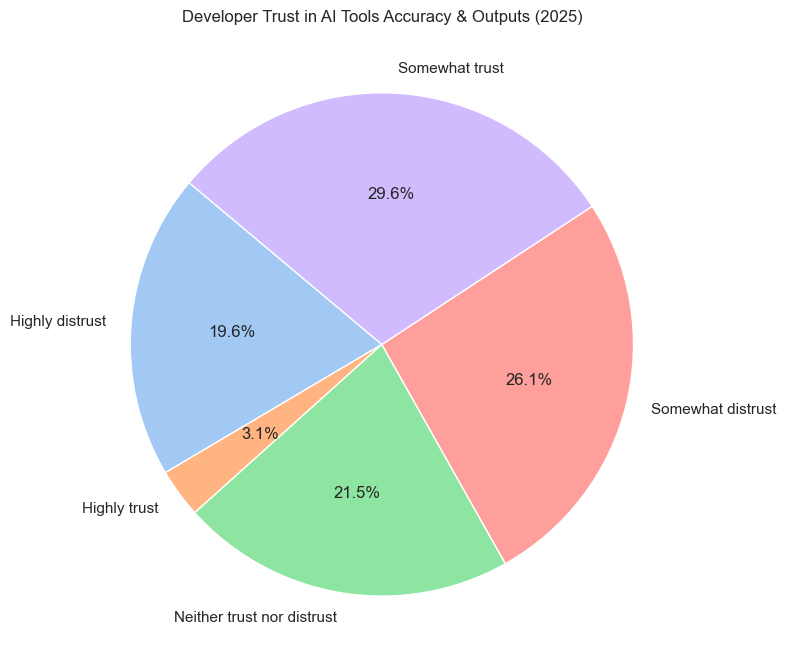

In [3]:
trust_query = """
SELECT 
    o.AIAcc AS AI_Trust,
    COUNT(DISTINCT f.ResponseKey) AS Count
FROM Snowflake.Fact_Survey_Core f
JOIN Snowflake.Dim_AICentral c ON f.Dim_AICentralID = c.Dim_AICentralID
JOIN Snowflake.Dim_AIOpinions o ON c.Dim_AIOpinionsID = o.Dim_AIOpinionsID
WHERE YEAR(f.SurveyYear) = 2025 
  AND o.AIAcc IS NOT NULL AND o.AIAcc <> '' AND o.AIAcc <> 'Unknown'
GROUP BY o.AIAcc;
"""
df_trust = db.read_query(trust_query)

if df_trust is not None and not df_trust.empty:
    plt.figure(figsize=(8, 8))
    colors = sns.color_palette('pastel')[0:5]
    plt.pie(df_trust['Count'], labels=df_trust['AI_Trust'], autopct='%1.1f%%', colors=colors, startangle=140)
    plt.title('Developer Trust in AI Tools Accuracy & Outputs (2025)')
    plt.tight_layout()
    plt.savefig(os.path.join(images_dir, '05_ai_trust.png'), dpi=300)
    plt.show()
else:
    print("No AI trust data available.")

### 3. Popular AI Search vs. AI Developer Tools (2025)

Let's see which AI tools are the most popular.

In [7]:
print(df_search)

Empty DataFrame
Columns: [AISearchTool, Count]
Index: []


Query executed successfully


c:\Users\Ayush\Git Repo\Stack-Over-Flow-Survey-Data-Engineering-Project\Data Warehouse\Silver Layer\utils\sql_connector.py:46: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql_query(query, self.conn)


Query executed successfully


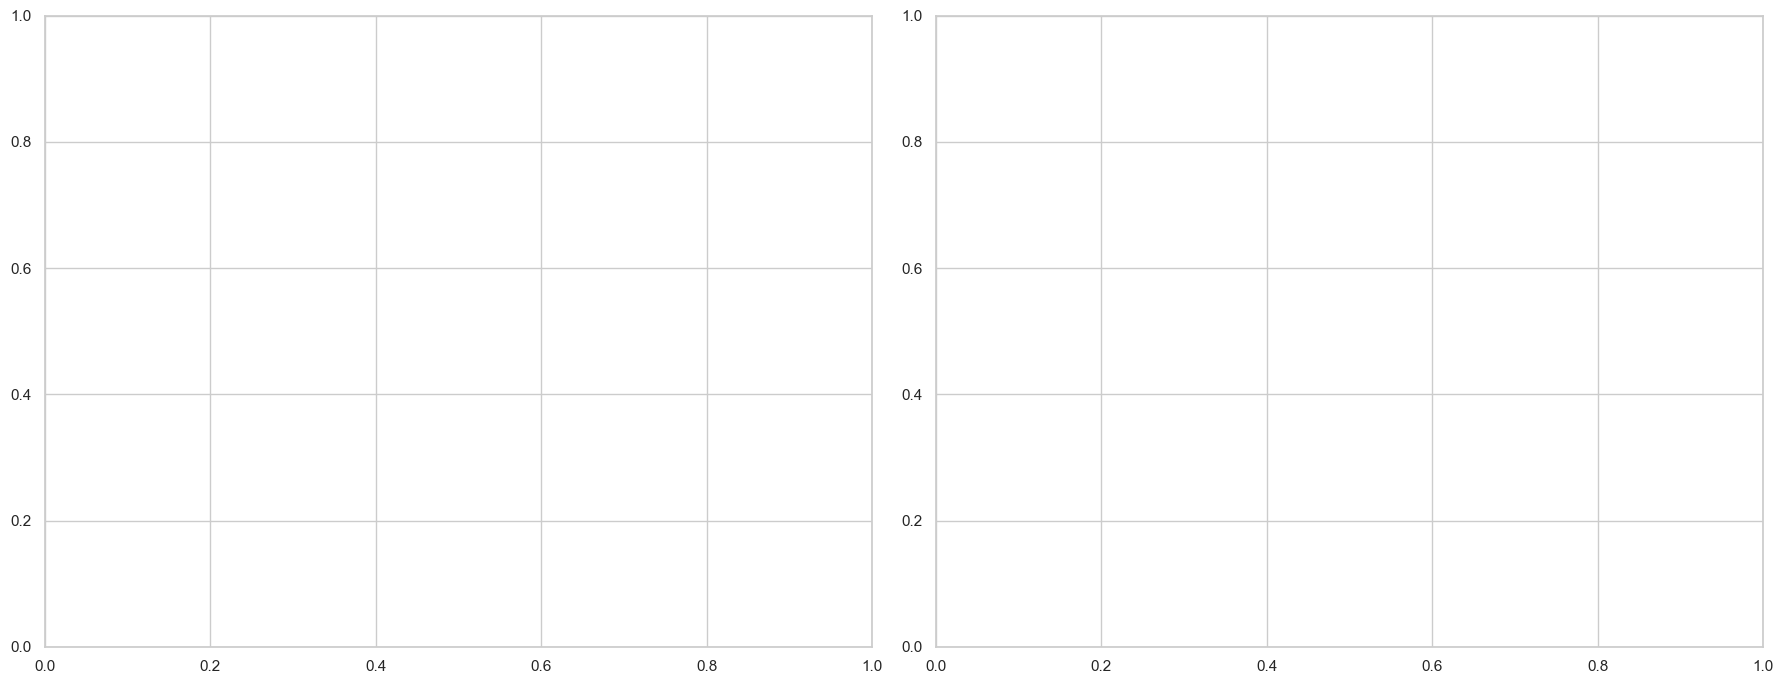

In [4]:
search_query = """
SELECT 
    b.AISearchHaveWorkedWith_Clean AS AISearchTool,
    COUNT(DISTINCT f.ResponseKey) AS Count
FROM Snowflake.Fact_Survey_Core f
JOIN Snowflake.Bridge_AISearchHaveWorkedWith_Clean b ON f.ResponseKey = b.ResponseKey
WHERE YEAR(f.SurveyYear) = 2025 AND b.AISearchHaveWorkedWith_Clean <> 'Unknown' AND b.AISearchHaveWorkedWith_Clean <> ''
GROUP BY b.AISearchHaveWorkedWith_Clean;
"""
dev_tool_query = """
SELECT 
    b.AIDevHaveWorkedWith_Clean AS AIDevTool,
    COUNT(DISTINCT f.ResponseKey) AS Count
FROM Snowflake.Fact_Survey_Core f
JOIN Snowflake.Bridge_AIDevHaveWorkedWith_Clean b ON f.ResponseKey = b.ResponseKey
WHERE YEAR(f.SurveyYear) = 2025 AND b.AIDevHaveWorkedWith_Clean <> 'Unknown' AND b.AIDevHaveWorkedWith_Clean <> ''
GROUP BY b.AIDevHaveWorkedWith_Clean;
"""

df_search = db.read_query(search_query)
df_dev = db.read_query(dev_tool_query)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

if df_search is not None and not df_search.empty:
    df_search_top = df_search.sort_values(by='Count', ascending=False).head(10)
    sns.barplot(data=df_search_top, x='Count', y='AISearchTool', palette='Blues_r', ax=axes[0])
    axes[0].set_title('Top AI Search Tools (2025)')
    axes[0].set_xlabel('Count')
    axes[0].set_ylabel('AI Search Tool')

if df_dev is not None and not df_dev.empty:
    df_dev_top = df_dev.sort_values(by='Count', ascending=False).head(10)
    sns.barplot(data=df_dev_top, x='Count', y='AIDevTool', palette='Oranges_r', ax=axes[1])
    axes[1].set_title('Top AI Developer Tools (2025)')
    axes[1].set_xlabel('Count')
    axes[1].set_ylabel('AI Developer Tool')

plt.tight_layout()
plt.savefig(os.path.join(images_dir, '05_top_ai_tools.png'), dpi=300)
plt.show()

### 4. AI Adoption Status by Key Developer Roles (2025)

Let's see if Data Scientists or Sysadmins are adopting AI tools faster.

c:\Users\Ayush\Git Repo\Stack-Over-Flow-Survey-Data-Engineering-Project\Data Warehouse\Silver Layer\utils\sql_connector.py:46: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql_query(query, self.conn)


Query executed successfully


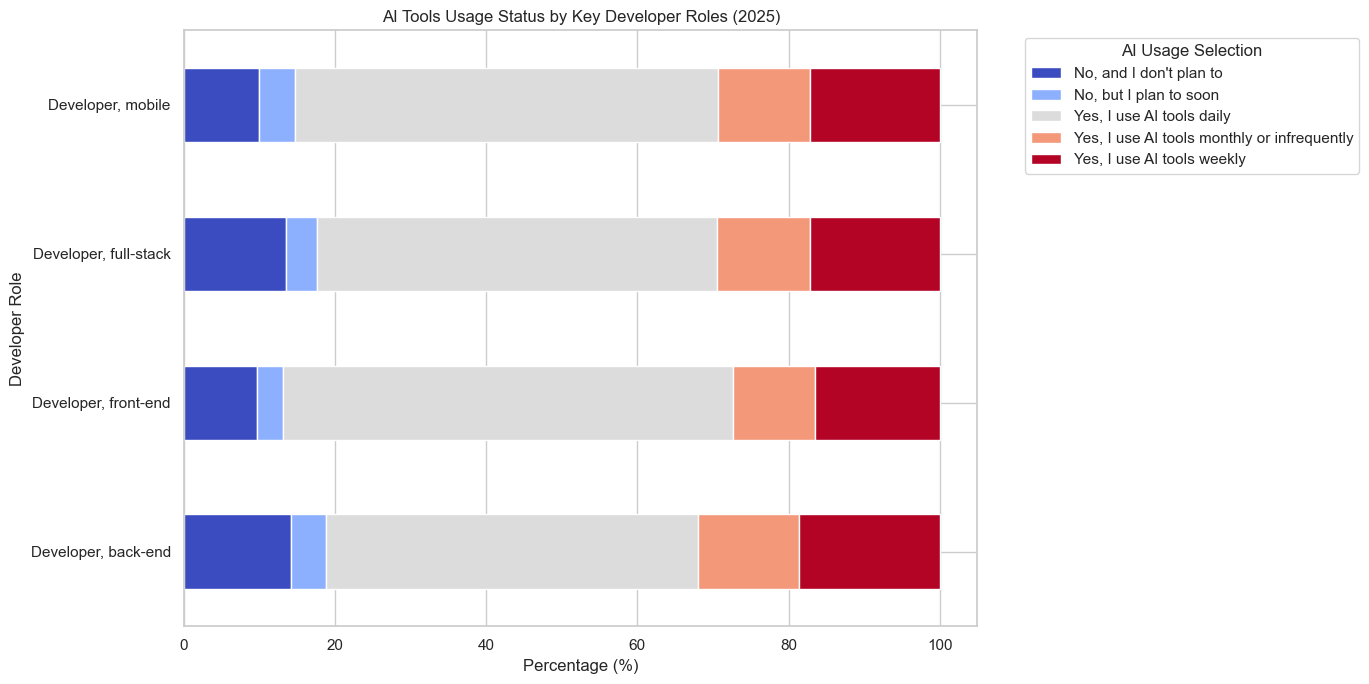

In [5]:
role_ai_query = """
SELECT 
    role.DevType_Clean AS DevRole,
    o.AISelect AS AI_Usage_Select,
    COUNT(DISTINCT f.ResponseKey) AS Count
FROM Snowflake.Fact_Survey_Core f
JOIN Snowflake.Bridge_DevType_Clean role ON f.ResponseKey = role.ResponseKey
JOIN Snowflake.Dim_AICentral c ON f.Dim_AICentralID = c.Dim_AICentralID
JOIN Snowflake.Dim_AIOpinions o ON c.Dim_AIOpinionsID = o.Dim_AIOpinionsID
WHERE YEAR(f.SurveyYear) = 2025
  AND o.AISelect IS NOT NULL AND o.AISelect <> 'Unknown' AND o.AISelect <> ''
  AND role.DevType_Clean IN ('Developer, full-stack', 'Developer, back-end', 'Developer, front-end', 'Data scientist or machine learning specialist', 'Developer, mobile', 'DevOps specialist')
GROUP BY role.DevType_Clean, o.AISelect;
"""
df_role_ai = db.read_query(role_ai_query)

if df_role_ai is not None and not df_role_ai.empty:
    df_role_pivot = df_role_ai.pivot(index='DevRole', columns='AI_Usage_Select', values='Count').fillna(0)
    df_role_pct = df_role_pivot.div(df_role_pivot.sum(axis=1), axis=0) * 100
    
    df_role_pct.plot(kind='barh', stacked=True, figsize=(14, 7), colormap='coolwarm')
    plt.title('AI Tools Usage Status by Key Developer Roles (2025)')
    plt.xlabel('Percentage (%)')
    plt.ylabel('Developer Role')
    plt.legend(title='AI Usage Selection', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.savefig(os.path.join(images_dir, '05_ai_adoption_by_role.png'), dpi=300)
    plt.show()
else:
    print("No role/AI data available.")

In [6]:
db.close()

Connection closed.
